# DreamerV3 Smoke Test — HM3D ObjectNav

**Goal:** Verify the DreamerV3 JAX training pipeline works end-to-end on HM3D ObjectNav.
Functional correctness: losses should trend downward.

**What we verify:**
1. Environment loads and filters easy episodes (geodesic < 5m)
2. Replay buffer fills correctly
3. Training loop runs, losses decrease
4. Save/load checkpoint works
5. Greedy eval produces actions

**Config:** 64x64 obs, ~1000 training steps, ~200 prefill, batch_size=4, seq_len=16

**Run on bwUniCluster:**
```bash
srun --partition=dev_gpu_h100 --gres=gpu:1 --time=00:30:00 uv run jupyter nbconvert --to notebook --execute notebooks/dreamerv3_smoke_test.ipynb --inplace
```

In [1]:
import os, sys
from pathlib import Path
from datetime import date

# Ensure project root is on path
project_root = Path(os.path.abspath("")).parent if Path(os.path.abspath("")).name == "notebooks" else Path(os.path.abspath(""))
os.chdir(project_root)
print(f"Working directory: {Path.cwd()}")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import wandb

from src.dreamerv3.configs import DreamerConfig
from src.dreamerv3.agent import DreamerAgent
from src.dreamerv3.replay_buffer import ReplayBuffer

print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")

Working directory: /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX devices: [CpuDevice(id=0)]
JAX backend: cpu


In [2]:
# Tiny config for quick validation
config = DreamerConfig(
    obs_shape=(3, 64, 64),
    max_episode_steps=200,
    split="val_mini",
    total_steps=1000,
    prefill_steps=200,
    batch_size=4,
    seq_len=16,
    save_every=500,
    log_every=50,
    buffer_capacity=10_000,
    logdir="output/dreamerv3-smoke",
    seed=42,
)

# WandB init
today = date.today().strftime("%Y%m%d")
wandb.init(
    project="dreamerv3-objectnav",
    name=f"smoke-jax-{today}",
    tags=["smoke-test", "jax"],
    config={
        "obs_shape": config.obs_shape,
        "total_steps": config.total_steps,
        "prefill_steps": config.prefill_steps,
        "batch_size": config.batch_size,
        "seq_len": config.seq_len,
        "hidden_size": config.hidden_size,
        "stoch_size": config.stoch_size,
        "lr_world": config.lr_world,
        "lr_actor": config.lr_actor,
        "lr_critic": config.lr_critic,
    },
)

print("Config:")
for f in ['obs_shape', 'max_episode_steps', 'split', 'total_steps',
          'prefill_steps', 'batch_size', 'seq_len', 'hidden_size', 'stoch_size']:
    print(f"  {f}: {getattr(config, f)}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/ul/ul_student/ul_hfj15/.netrc.


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: setting up run mym3hxgi


wandb: Tracking run with wandb version 0.25.1


wandb: Run data is saved locally in /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/wandb/run-20260326_070921-mym3hxgi
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run smoke-jax-20260326


wandb: ⭐️ View project at https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav


wandb: 🚀 View run at https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav/runs/mym3hxgi


Config:
  obs_shape: (3, 64, 64)
  max_episode_steps: 200
  split: val_mini
  total_steps: 1000
  prefill_steps: 200
  batch_size: 4
  seq_len: 16
  hidden_size: 512
  stoch_size: 1024


In [3]:
# Create environment with easy episode filter
from src.dreamerv3.env_habitat import HabitatObjectNavEnv

env = HabitatObjectNavEnv(config, max_geodesic=5.0)

# Verify
obs = env.reset()
print(f"\nFirst observation:")
print(f"  image shape: {obs['image'].shape} dtype: {obs['image'].dtype}")
print(f"  is_first: {obs['is_first']}")
print(f"  Episode: {env._env.current_episode.episode_id}")
print(f"  Target: {env._env.current_episode.object_category}")
print(f"  Geodesic: {env._env.current_episode.info.get('geodesic_distance', '?'):.2f}m")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


2026-03-26 07:09:44,151 Initializing dataset ObjectNav-v1


2026-03-26 07:09:44,195 initializing sim Sim-v0


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:09:44:639566]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hm3d_annotated_basis' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
[07:09:44:646179]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` does not exist.  Aborting load.
[07:09:44:646353]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticScen

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

In [4]:
# Prefill buffer with random actions
buffer = ReplayBuffer(config)

obs = env.reset()
for i in range(config.prefill_steps):
    action = np.random.randint(0, config.num_actions)
    next_obs = env.step(action)
    buffer.add(obs["image"], action, next_obs["reward"], next_obs["done"])
    obs = next_obs if not next_obs["done"] else env.reset()

print(f"Buffer size after prefill: {buffer.size}")
print(f"Buffer capacity: {buffer.capacity}")

# Verify sampling works
batch = buffer.sample(config.batch_size, config.seq_len)
print(f"\nSample batch shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape} {v.dtype}")

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:09:46:537755]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` does not exist.  Aborting load.
[07:09:46:537912]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/info_semantic.j

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:09:48:109942]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` does not exist.  Aborting load.
[07:09:48:110036]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/info_semantic.j

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

...

PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:09:54:520150]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` does not exist.  Aborting load.
[07:09:54:520200]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/info_semantic.json` exist on disk.
[07:09:54:520214]:[Error]:[Scene] SemanticScene.cpp(140

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:09:56:365457]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` does not exist.  Aborting load.
[07:09:56:365506]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/info_semantic.j

Buffer size after prefill: 200
Buffer capacity: 10000



Sample batch shapes:
  obs: (4, 16, 3, 64, 64) float32
  actions: (4, 16) int32
  rewards: (4, 16) float32
  dones: (4, 16) float32
  is_first: (4, 16) float32


In [5]:
# Train for ~1000 steps — track metrics
rng_key = jax.random.PRNGKey(config.seed)
rng_key, init_key = jax.random.split(rng_key)
agent = DreamerAgent(config, init_key)

obs = env.reset()
episode_reward = 0.0
episode_count = 0
metrics_log = []  # (step, metrics_dict)
episode_log = []  # (step, reward, success)

print(f"Training for {config.total_steps} steps...")
for step in range(config.total_steps):
    rng_key, act_key, train_key = jax.random.split(rng_key, 3)

    action = agent.act(obs, act_key)
    next_obs = env.step(action)
    buffer.add(obs["image"], action, next_obs["reward"], next_obs["done"])
    episode_reward += next_obs["reward"]

    if next_obs["done"]:
        episode_count += 1
        episode_log.append((step, episode_reward, next_obs.get("success", 0.0)))
        wandb.log({
            "episode/reward": episode_reward,
            "episode/success": next_obs.get("success", 0.0),
            "episode/count": episode_count,
        }, step=step)
        episode_reward = 0.0
        obs = env.reset()
    else:
        obs = next_obs

    if buffer.size >= config.batch_size * config.seq_len:
        batch = buffer.sample(config.batch_size, config.seq_len)
        metrics = agent.train_step(batch, train_key)

        if step % config.log_every == 0:
            metrics_log.append((step, {k: float(v) for k, v in metrics.items()}))
            wandb.log({f"train/{k}": float(v) for k, v in metrics.items()}, step=step)
            print(f"  [step {step:>5}] wm={metrics['wm_loss']:.3f} "
                  f"actor={metrics['actor_loss']:.3f} critic={metrics['critic_loss']:.3f} "
                  f"ep={episode_count}")

    if step > 0 and step % config.save_every == 0:
        agent.save(config.logdir)
        print(f"  [step {step}] Checkpoint saved")

agent.save(config.logdir)
print(f"\nDone. {episode_count} episodes, {len(metrics_log)} metric snapshots.")

Training for 1000 steps...


  [step     0] wm=1.888 actor=0.030 critic=0.005 ep=0


Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:10:52:017814]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` does not exist.  Aborting load.
[07:10:52:017876]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/info_semantic.j

  [step    50] wm=1.498 actor=-0.008 critic=0.003 ep=10


...

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:23:47:774906]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` does not exist.  Aborting load.
[07:23:47:774954]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00800-TEEsavR23oF/info_semantic.j

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[07:23:59:324580]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` does not exist.  Aborting load.
[07:23:59:324630]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/info_semantic.j


Done. 242 episodes, 20 metric snapshots.


In [6]:
# Verify save/load
rng_key, reload_key = jax.random.split(rng_key)
agent2 = DreamerAgent(config, reload_key)
agent2.load(config.logdir)

# Compare params
orig_flat = jax.tree.leaves(agent.wm_state.params)
loaded_flat = jax.tree.leaves(agent2.wm_state.params)
all_match = all(jnp.allclose(a, b) for a, b in zip(orig_flat, loaded_flat))
print(f"Params match after save/load: {all_match}")
assert all_match, "Checkpoint save/load mismatch!"

Params match after save/load: True


In [7]:
# Quick greedy eval (5 episodes)
print("Greedy eval (5 episodes):")
eval_results = []
for ep in range(5):
    obs = env.reset()
    ep_reward, steps = 0.0, 0
    rng_key, act_key = jax.random.split(rng_key)

    while not obs.get("done", False) and steps < config.max_episode_steps:
        action = agent2.act(obs, act_key, training=False)
        obs = env.step(action)
        ep_reward += obs["reward"]
        steps += 1

    cat = getattr(env._env.current_episode, "object_category", "?")
    print(f"  ep {ep+1}: reward={ep_reward:+.2f} success={obs.get('success',0):.0f} "
          f"steps={steps} target={cat}")
    eval_results.append({"reward": ep_reward, "success": obs.get("success", 0), "steps": steps})

env.close()
print(f"\nMean reward: {np.mean([r['reward'] for r in eval_results]):.2f}")
print(f"SR: {np.mean([r['success'] for r in eval_results]):.2f}")
print("(SR~0 expected after only 5k steps — this just verifies the pipeline works)")

Greedy eval (5 episodes):


  ep 1: reward=+0.00 success=0 steps=2 target=sofa
  ep 2: reward=+0.26 success=0 steps=3 target=chair
  ep 3: reward=+0.10 success=0 steps=11 target=tv_monitor
  ep 4: reward=+0.00 success=0 steps=1 target=bed


  ep 5: reward=-0.04 success=0 steps=7 target=plant

Mean reward: 0.06
SR: 0.00
(SR~0 expected after only 5k steps — this just verifies the pipeline works)


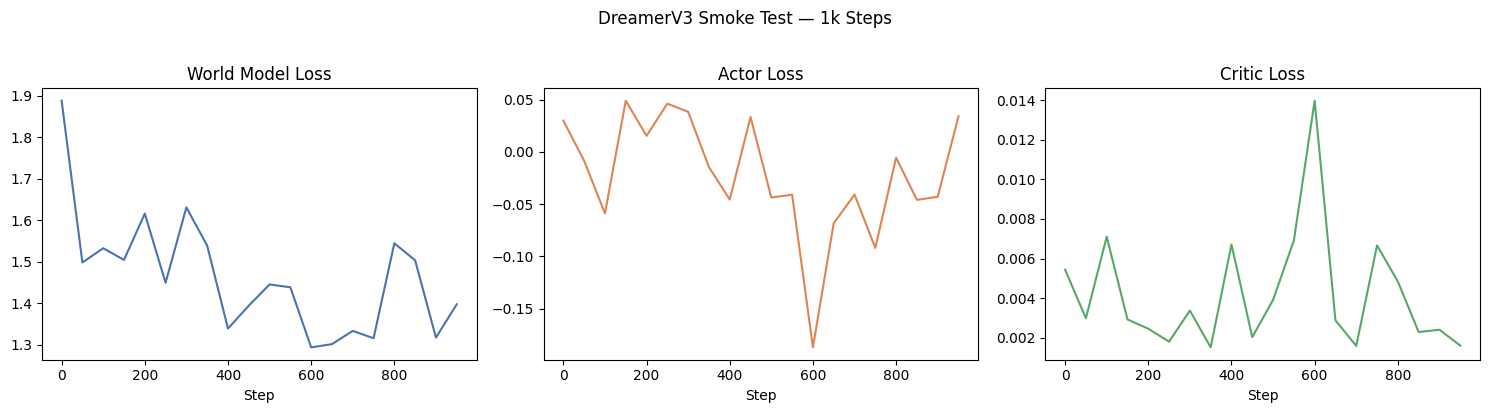

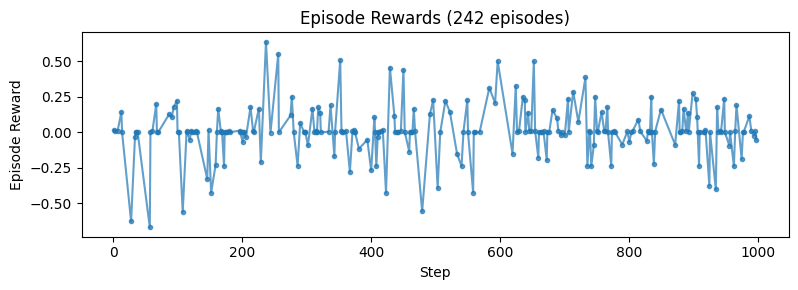

wandb: updating run metadata


wandb: uploading history steps 249-254, summary


wandb: 
wandb: Run history:
wandb:     episode/count ▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██████
wandb:    episode/reward ▅▅▅▆▅▅▅▅▅▅▅▅▅▅▅▄▅▆▁▆▅▅█▅▆▄▅▅▄▅▆▆▅▃▅▂▄▅▅▄
wandb:   episode/success ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  train/actor_loss ▇▆▅█▇██▆▅█▅▅▁▅▅▄▆▅▅█
wandb:   train/cont_loss █▄▅▅▆▃▇▅▂▃▄▃▁▁▂▁▅▅▁▃
wandb: train/critic_loss ▃▂▄▂▂▁▂▁▄▁▂▄█▂▁▄▃▁▂▁
wandb:     train/entropy ▁▃▅▄▅▅▆▆▇▇▇▇█▇██████
wandb: train/imag_return ▂▃▄▁▂▁▁▃▄▁▄▄█▄▄▅▃▄▄▁
wandb: train/imag_reward ▁▄█▁▃▁▂▄▅▂▆▅█▅▆▆▃▅▄▂
wandb:     train/kl_loss ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                +3 ...
wandb: 
wandb: Run summary:
wandb:     episode/count 242
wandb:    episode/reward -0.05282
wandb:   episode/success 0
wandb:  train/actor_loss 0.03409
wandb:   train/cont_loss 0.38248
wandb: train/critic_loss 0.0016
wandb:     train/entropy 1.38618
wandb: train/imag_return -0.0345
wandb: train/imag_reward -0.00985
wandb:     train/kl_loss 1
wandb:                +3 ...
wandb: 


wandb: 🚀 View run smoke-jax-20260326 at: https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav/runs/mym3hxgi
wandb: ⭐️ View project at: https://wandb.ai/sailer-luca-university-ulm/dreamerv3-objectnav
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260326_070921-mym3hxgi/logs


Smoke test complete. All systems operational.


In [8]:
# Plot training curves
if metrics_log:
    steps_arr = [m[0] for m in metrics_log]
    wm = [m[1]["wm_loss"] for m in metrics_log]
    actor = [m[1]["actor_loss"] for m in metrics_log]
    critic = [m[1]["critic_loss"] for m in metrics_log]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(steps_arr, wm, color="#4C72B0")
    axes[0].set_title("World Model Loss")
    axes[0].set_xlabel("Step")

    axes[1].plot(steps_arr, actor, color="#DD8452")
    axes[1].set_title("Actor Loss")
    axes[1].set_xlabel("Step")

    axes[2].plot(steps_arr, critic, color="#55A868")
    axes[2].set_title("Critic Loss")
    axes[2].set_xlabel("Step")

    plt.suptitle("DreamerV3 Smoke Test — 1k Steps", y=1.02)
    plt.tight_layout()
    plt.show()

    # Episode rewards
    if episode_log:
        ep_steps = [e[0] for e in episode_log]
        ep_rewards = [e[1] for e in episode_log]
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(ep_steps, ep_rewards, 'o-', markersize=3, alpha=0.7)
        ax.set_xlabel("Step")
        ax.set_ylabel("Episode Reward")
        ax.set_title(f"Episode Rewards ({len(episode_log)} episodes)")
        plt.tight_layout()
        plt.show()

wandb.finish()
print("Smoke test complete. All systems operational.")